In [36]:
from skimage import io, color, morphology
from skimage.util import img_as_float, img_as_ubyte
import matplotlib.pyplot as plt
import numpy as np
import math
from skimage.filters import threshold_otsu
from skimage import segmentation
from skimage import measure
from skimage.color import label2rgb
import cv2
from utils import plot_comparison


In [3]:
path = "/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/imageAnalysisGithub/exercises/ex5-BLOBAnalysis/data/"

/tmp/ipykernel_288748/51106336.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img)
/tmp/ipykernel_288748/51106336.py:3: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


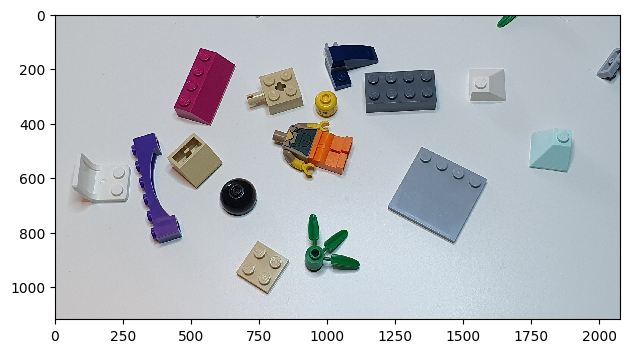

In [ ]:
img = io.imread(path + "lego_4_small.png")
io.imshow(img)
io.show()



threshold detected 140


/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/02515_Image_Analysis_Github/exam_practice_sets/utils.py:32: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


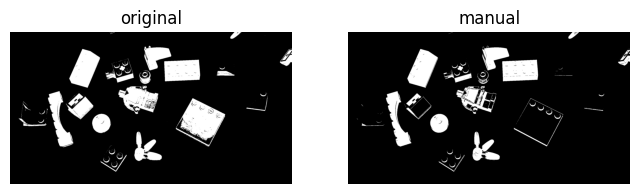

In [ ]:
# Lx-5.1 Preprocess a color image so its suitable for BLOB analysis using color to gray and threshold selection

img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
thresh = threshold_otsu(img_gray)
print(f"threshold detected {thresh}")
man_thresh = 120
bin_img = img_gray < thresh
bin_img_man = img_gray < man_thresh
plot_comparison(bin_img, bin_img_man, "manual")


type of image bool
(1119, 2077)


/tmp/ipykernel_288748/639466543.py:6: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(bin_img[row,col])
/tmp/ipykernel_288748/639466543.py:7: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


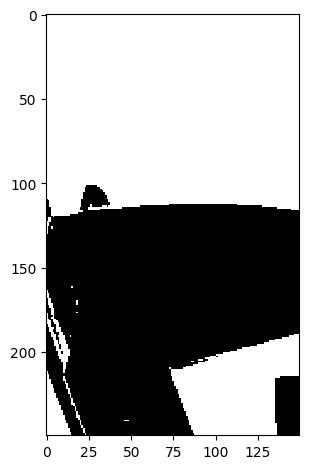

In [18]:
# Lx-5.2 Use slicing to extract regions of an image for further analysis
print(f"type of image {bin_img.dtype}")
print(bin_img.shape)
row = slice(0,250)
col = slice(1000,1150)
io.imshow(bin_img[row,col])
io.show()

/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/02515_Image_Analysis_Github/exam_practice_sets/utils.py:32: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


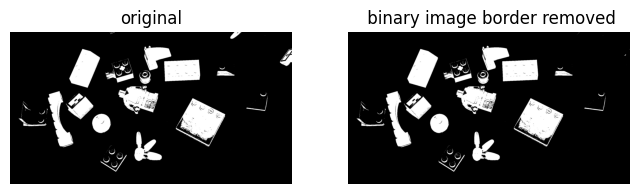

In [23]:
# Lx-5.3 Use segmentation.clear_border to remove border BLOBs

im_process = segmentation.clear_border(bin_img)
plot_comparison(bin_img,im_process," binary image border removed")

/tmp/ipykernel_288748/3188302990.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


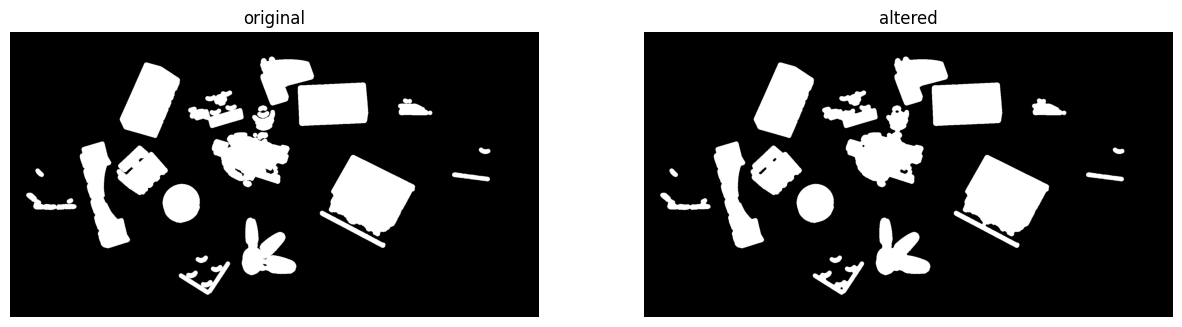

In [49]:
# Lx-5.4 Apply suitable morphological operations to remove small BLOBs, close holes and generally make a binary image suitable for BLOB analysis 

def plot_comparison(original, filtered, filter_name, x_dimension, y_dimension):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(x_dimension, y_dimension), sharex=True, sharey=True)
    ax1.imshow(original, cmap=plt.cm.gray)
    ax1.set_title('original')
    ax1.axis('off')
    ax2.imshow(filtered, cmap=plt.cm.gray)
    ax2.set_title(filter_name)
    ax2.axis('off')
    io.show()


from skimage.morphology import erosion, dilation, opening, closing, disk
structure = disk(9)
img_processed = im_process

opened = opening(img_processed, disk(3))


dilated = dilation(opened, disk(6))

closed = closing(dilated, disk(4))

plot_comparison(dilated, closed, "altered",  15, 15 )


In [50]:
# Lx-5.5 Use measure.label to create labels from a binary image
label_img = measure.label(closed)
n_labels = label_img.max()
print(f"Number of labels: {n_labels}")


Number of labels: 18


/tmp/ipykernel_288748/3437462749.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


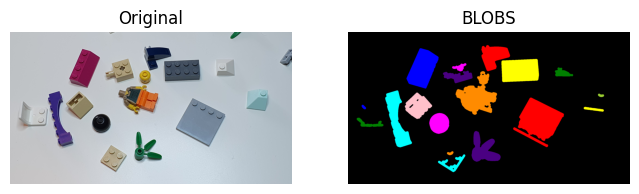

In [52]:
# Lx-5.6 Visualize labels 
def show_comparison(original, modified, modified_name):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 4), sharex=True,
                                   sharey=True)
    ax1.imshow(original)
    ax1.set_title('Original')
    ax1.axis('off')
    ax2.imshow(modified)
    ax2.set_title(modified_name)
    ax2.axis('off')
    io.show()
im_blob = label2rgb(label_img)
show_comparison(img, im_blob, 'BLOBS')

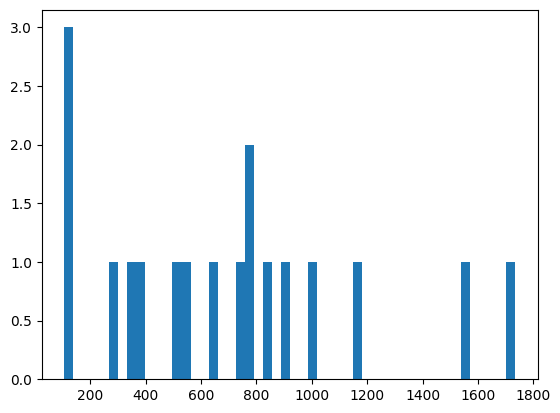

In [59]:
# Lx-5.7 Compute BLOB features using measure.regionprops, including BLOB area and perimeter

region_props = measure.regionprops(label_img)
perimeter = np.array([prop.perimeter for prop in region_props])
plt.hist(perimeter, bins=50)
plt.show()

Valid BLOBs remaining: 15, previous was: 18


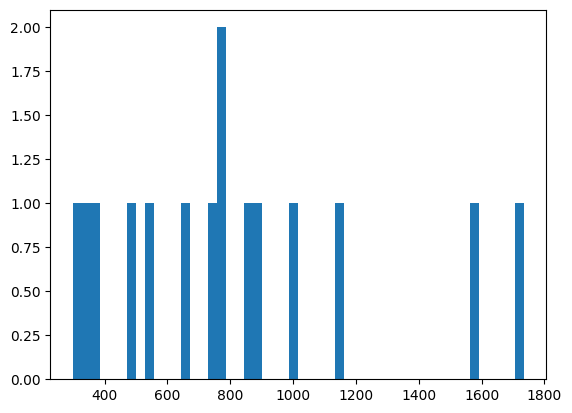

In [63]:
# Lx-5.8 Remove BLOBs that have certain feature

thresh_perimeter = 200
valid =np.array([prop.perimeter for prop in region_props if prop.perimeter > thresh_perimeter])
print(f"Valid BLOBs remaining: {len(valid)}, previous was: {len(perimeter)}")

plt.hist(valid, bins = 50)
plt.show()
